C:\Users\88692\AppData\Local\Temp\ipykernel_26160\1274858111.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_corr_display.values, y=price_corr_display.index, palette='RdYlBu_r')


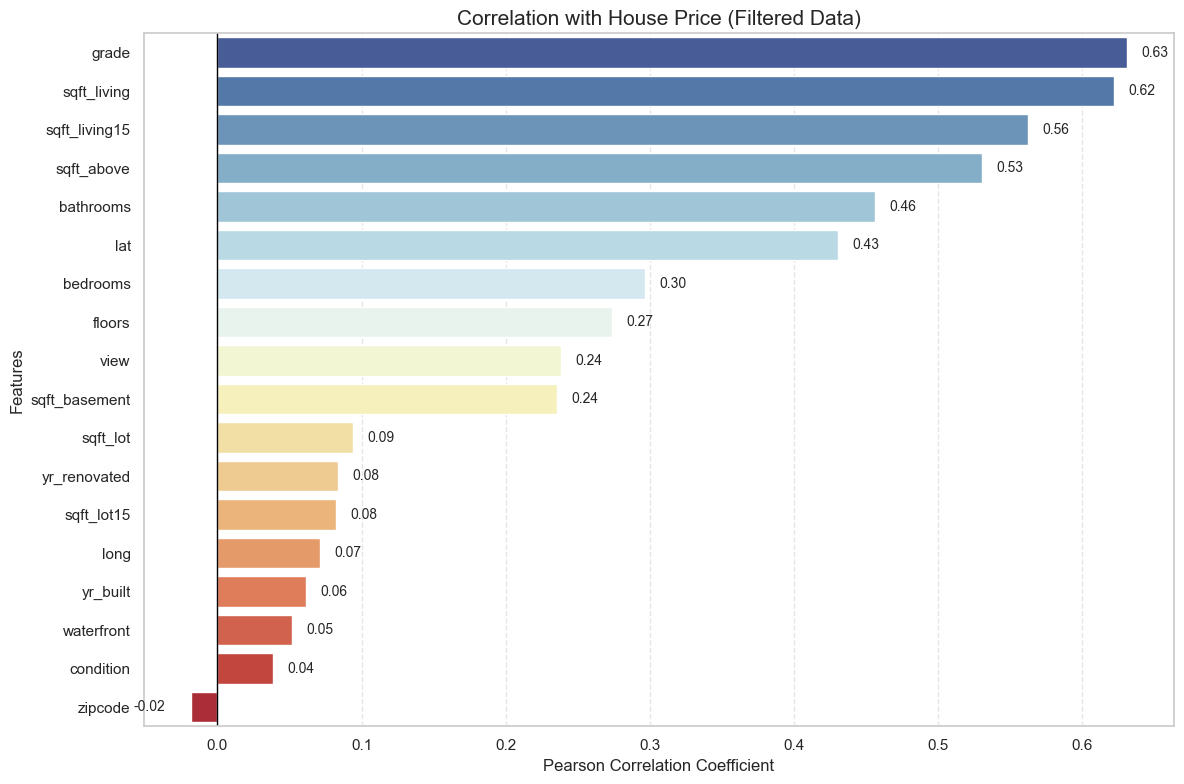

原始資料筆數: 21613
清洗後剩餘筆數: 20467
相關性最強指標: grade (0.63)


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 讀取資料
# 從原始 CSV 檔案載入數據
df = pd.read_csv('HW1_house_data.csv')

# 2. 資料清洗：使用 IQR (四分位距) 法剔除房價離群值
# 這是為了讓分析結果更貼近一般房屋市場，不受極端豪宅影響
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# 定義合理的房價範圍
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 執行過濾並刪除缺失值
df_filtered = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()
df_filtered = df_filtered.dropna()

# 3. 準備相關性數據
# 僅挑選數值型欄位，並排除無意義的 ID 欄位
numeric_df = df_filtered.select_dtypes(include=[np.number]).drop(columns=['id'], errors='ignore')

# 4. 計算 Pearson 相關係數
corr_matrix = numeric_df.corr()

# 5. 取得所有欄位與 'price' 的相關性並排序
# 排除 price 與自身的相關性 (1.0)
price_corr = corr_matrix['price'].sort_values(ascending=False)
price_corr_display = price_corr.drop('price')

# 6. 繪製視覺化圖表
plt.figure(figsize=(12, 8))
# 使用紅黃藍漸層配色，凸顯相關性強度
sns.barplot(x=price_corr_display.values, y=price_corr_display.index, palette='RdYlBu_r')

# 在長條圖末端標註具體的相關係數數值
for i, v in enumerate(price_corr_display.values):
    plt.text(v + 0.01 if v >= 0 else v - 0.04, i, f'{v:.2f}', va='center', fontsize=10)

plt.title('Correlation with House Price (Filtered Data)', fontsize=15)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', lw=1) # 畫出 0 基準線
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 輸出基本統計報告
print(f"原始資料筆數: {len(df)}")
print(f"清洗後剩餘筆數: {len(df_filtered)}")
print(f"相關性最強指標: {price_corr_display.index[0]} ({price_corr_display.values[0]:.2f})")

In [21]:
# 2. 敘述性統計分析
# 針對關鍵特徵產出統計摘要[cite: 2]
key_features = ['price', 'sqft_living', 'bedrooms', 'bathrooms', 'grade']
print("--- 敘述性統計結果 ---")
print(df_filtered[key_features].describe())

# 4. 特徵相關性分析
# 計算數值型欄位與 price 的 Pearson 相關係數[cite: 2]
numeric_df = df_filtered.select_dtypes(include=[np.number]).drop(columns=['id'], errors='ignore')
corr_matrix = numeric_df.corr()
price_corr = corr_matrix['price'].sort_values(ascending=False).drop('price')

--- 敘述性統計結果 ---
              price   sqft_living      bedrooms     bathrooms         grade
count  2.046700e+04  20467.000000  20467.000000  20467.000000  20467.000000
mean   4.769846e+05   1975.558167      3.329750      2.051632      7.530561
std    2.083713e+05    774.833460      0.912885      0.711906      1.039192
min    7.500000e+04    290.000000      0.000000      0.000000      1.000000
25%    3.150000e+05   1400.000000      3.000000      1.500000      7.000000
50%    4.375000e+05   1860.000000      3.000000      2.000000      7.000000
75%    6.000000e+05   2431.000000      4.000000      2.500000      8.000000
max    1.127500e+06   7480.000000     33.000000      7.500000     12.000000


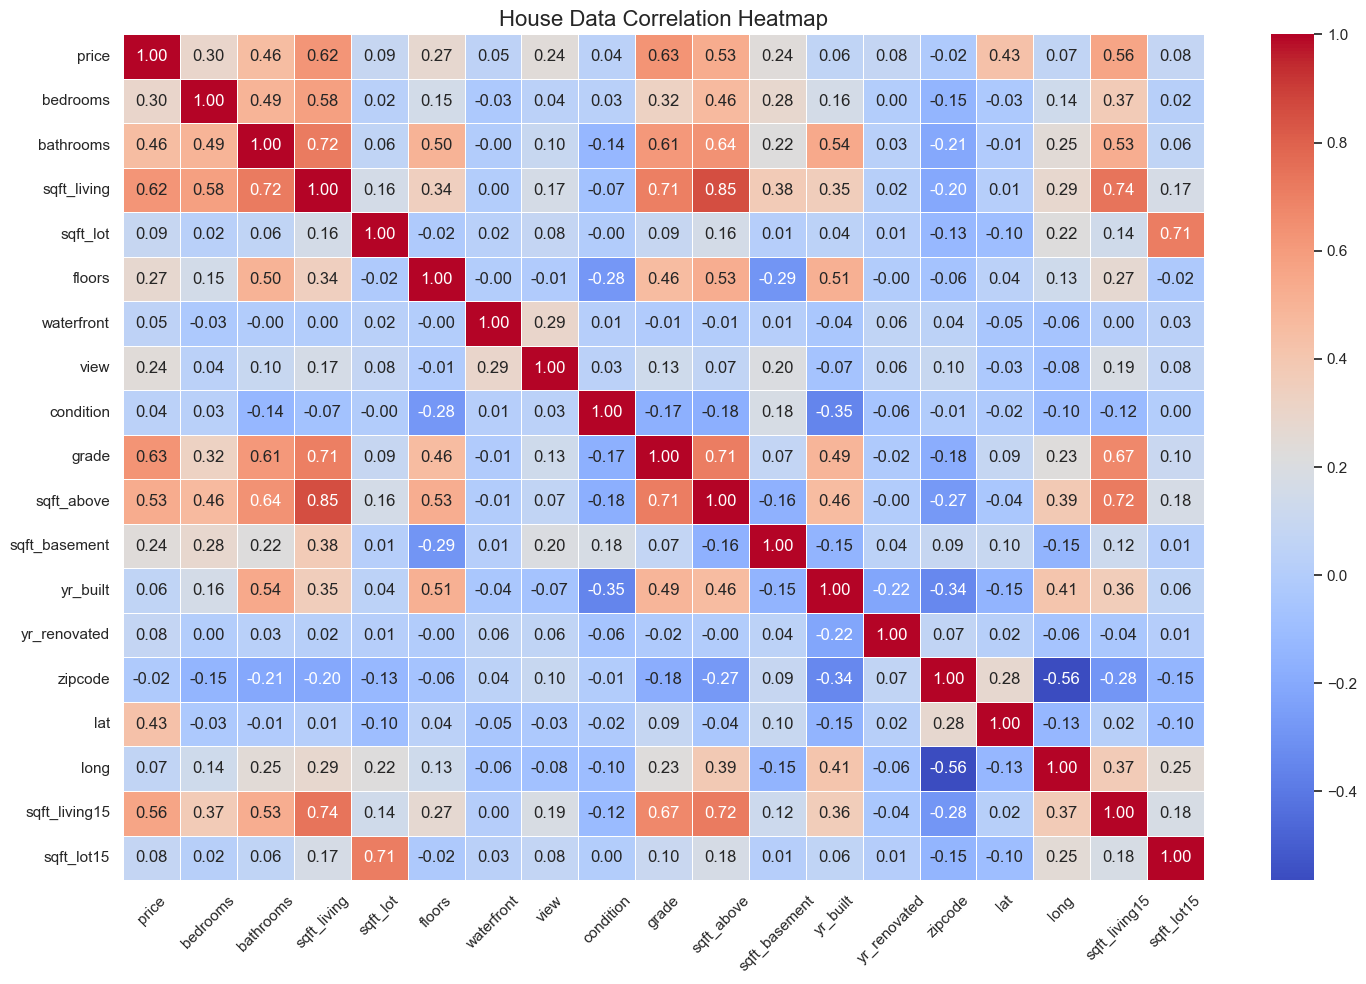

In [27]:
# 3.特徵相關性分析
# 繪製熱力圖 (Heatmap)
plt.figure(figsize=(15, 10))

# 使用 seaborn 繪製
# annot=True 顯示數值, cmap 設定顏色, fmt='.2f' 保留兩位小數
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('House Data Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

In [25]:
def map_grade(g):
    if g >= 9:
        return 1
    elif g >= 7:
        return 2
    else:
        return 3

df_modified['grade_class'] = df_modified['grade'].apply(map_grade)

# 5. 儲存修改後的資料為 CSV
output_name = 'HW1_house_data_modified.csv'
df_modified.to_csv(output_name, index=False)

# 6. 印出處理報告
print(f"--- 資料處理報告 ---")
print(f"原始資料筆數: {len(df)}")
print(f"清洗後資料筆數: {len(df_modified)}")
print(f"剔除筆數: {len(df) - len(df_modified)}")
print(f"房價過濾區間: ${actual_lower:,.0f} - ${upper_bound:,.0f}")
print(f"新檔案已儲存至: {output_name}")

--- 資料處理報告 ---
原始資料筆數: 21613
清洗後資料筆數: 20467
剔除筆數: 1146
房價過濾區間: $0 - $1,129,575
新檔案已儲存至: HW1_house_data_modified.csv


In [28]:
# 4. 資料分割與建置迴歸模型
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 選擇特徵 X 與目標 y
# 基於相關性分析結果，選取最關鍵的 7 個特徵
features = ['sqft_living', 'grade', 'sqft_above', 'bathrooms', 'view', 'sqft_living15', 'lat']
X = df_filtered[features]
y = df_filtered['price']

# 執行資料分割：80% 訓練, 20% 測試，設定 random_state 確保結果可重複
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 建置線性迴歸模型並開始訓練
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
# 5. 模型效能評估
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 使用測試集進行預測
y_pred = lr_model.predict(X_test)

# 計算各項評估指標
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R-squared Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

R-squared Score: 0.6292
Mean Absolute Error (MAE): 93103.72
Root Mean Squared Error (RMSE): 124258.18


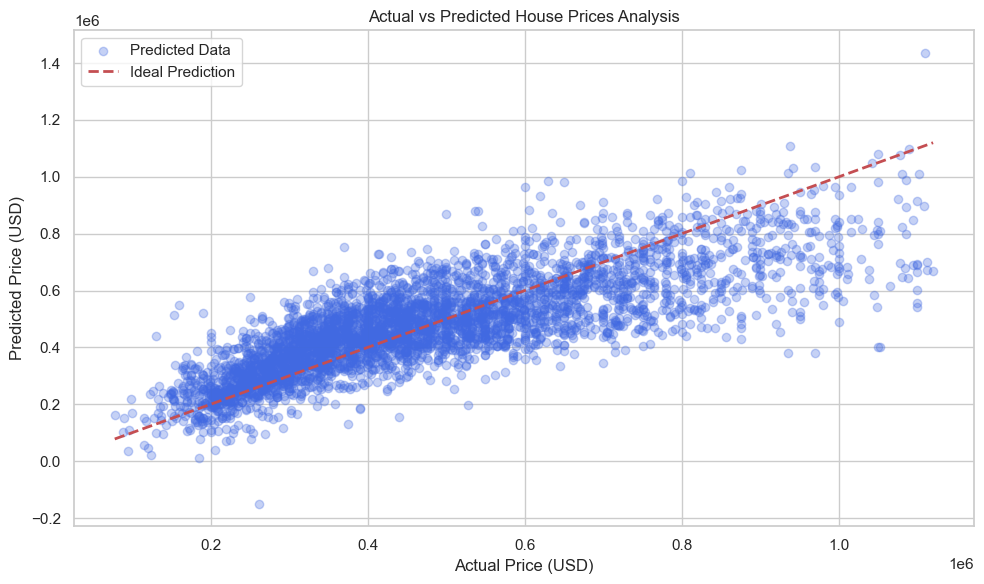

In [31]:
# 6. 預測結果分析
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# 繪製真實值 vs 預測值的散佈圖
plt.scatter(y_test, y_pred, alpha=0.3, color='royalblue', label='Predicted Data')
# 繪製 45 度理想參考線
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2, label='Ideal Prediction')

plt.title('Actual vs Predicted House Prices Analysis')
plt.xlabel('Actual Price (USD)')
plt.ylabel('Predicted Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline # 建議使用 Pipeline 比較整潔

# 1. 特徵變換與目標對數化
y_log = np.log1p(y)

# 2. 建立一個包含「多項式 -> 標準化 -> Ridge」的管道
# 這樣可以自動處理數據，防止數值爆炸
model_pipeline = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(), # 重要：加入標準化
    RidgeCV(alphas=[0.001, 0.01, 0.1, 1.0, 10.0, 100.0], scoring='r2')
)

# 3. 分割數據 (這裡使用原始 X, y_log)
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X, y_log, test_size=0.2, random_state=42)

# 4. 訓練管道
model_pipeline.fit(X_train_p, y_train_p)

# 5. 預測
y_pred_log = model_pipeline.predict(X_test_p)

# 6. 安全地轉回原始單位
# 限制預測值上限，避免 exp 爆炸 (房價對數通常在 10~20 之間)
y_pred_log = np.clip(y_pred_log, None, 20) 
y_pred_ridge = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test_p)

# 取得最佳 alpha (從 pipeline 中提取)
best_alpha = model_pipeline.named_steps['ridgecv'].alpha_
print(f"最佳 Alpha 值: {best_alpha}")

最佳 Alpha 值: 0.001


In [44]:
# 9. 相關模型結果比較分析
import pandas as pd
from IPython.display import display

# --- A. 計算基礎模型指標 (假設 y_test, y_base_pred 已存在) ---
# 如果你之前的變數名稱不同，請自行替換
r2_base = r2_score(y_test, y_base_pred)
mae_base = mean_absolute_error(y_test, y_base_pred)

# --- B. 計算進階模型指標 (對應你提供的程式碼變數) ---
r2_ridge = r2_score(y_test_orig, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test_orig, y_pred_ridge)

# --- C. 計算改善幅度 ---
improvement_r2 = ((r2_ridge - r2_base) / r2_base) * 100
improvement_mae = ((mae_base - mae_ridge) / mae_base) * 100

# --- D. 建立對照表格 ---
comparison_data = {
    "評估指標": ["Alpha 參數", "R2 (解釋力)", "MAE (平均誤差)"],
    "基礎線性迴歸 (Baseline)": [
        "無 (等於 0)", 
        f"{r2_base:.4f}", 
        f"${mae_base:,.0f}"
    ],
    "進階正規化模型 (Ridge + Poly)": [
        f"{ridge_cv.alpha_} (自動選定)", 
        f"{r2_ridge:.4f}", 
        f"${mae_ridge:,.0f}"
    ],
    "改善幅度": [
        "-", 
        f"提升約 {improvement_r2:.1f}%", 
        f"下降約 {improvement_mae:.1f}%"
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# 在 Jupyter Notebook 中漂亮地顯示表格
print("--- 模型效能對照表 ---")
display(df_comparison)

--- 模型效能對照表 ---


,評估指標,基礎線性迴歸 (Baseline),進階正規化模型 (Ridge + Poly),改善幅度
0,Alpha 參數,無 (等於 0),0.001 (自動選定),-
1,R2 (解釋力),0.6292,0.6650,提升約 5.7%
2,MAE (平均誤差),"$93,104","$85,544",下降約 8.1%


In [ ]:
# XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX

In [2]:
import numpy as np
import pandas as pd
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

NumPy version: 1.26.4
Pandas version: 2.2.2


In [4]:
import sys
!{sys.executable} -m pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp311-cp311-win_amd64.whl (8.1 MB)
